<a href="https://colab.research.google.com/github/MuridaM/market-volatility-prediction/blob/main/financial_market_volatility_analysis_and_predictive_modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Linear regression**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
url = "https://raw.githubusercontent.com/datasets/finance-vix/master/data/vix-daily.csv"
df = pd.read_csv(url)
print(df)

            DATE   OPEN   HIGH    LOW  CLOSE
0     01/02/1990  17.24  17.24  17.24  17.24
1     01/03/1990  18.19  18.19  18.19  18.19
2     01/04/1990  19.22  19.22  19.22  19.22
3     01/05/1990  20.11  20.11  20.11  20.11
4     01/08/1990  20.26  20.26  20.26  20.26
...          ...    ...    ...    ...    ...
9157  04/07/2026  25.09  28.00  24.34  25.78
9158  04/08/2026  20.97  22.17  19.91  21.04
9159  04/09/2026  21.25  21.63  19.45  19.49
9160  04/10/2026  19.71  20.28  18.83  19.23
9161  04/13/2026  21.17  21.58  18.96  19.12

[9162 rows x 5 columns]


In [ ]:
df['DATE'] = pd.to_datetime(df['DATE'])
print(df)

           DATE   OPEN   HIGH    LOW  CLOSE
0    1990-01-02  17.24  17.24  17.24  17.24
1    1990-01-03  18.19  18.19  18.19  18.19
2    1990-01-04  19.22  19.22  19.22  19.22
3    1990-01-05  20.11  20.11  20.11  20.11
4    1990-01-08  20.26  20.26  20.26  20.26
...         ...    ...    ...    ...    ...
9157 2026-04-07  25.09  28.00  24.34  25.78
9158 2026-04-08  20.97  22.17  19.91  21.04
9159 2026-04-09  21.25  21.63  19.45  19.49
9160 2026-04-10  19.71  20.28  18.83  19.23
9161 2026-04-13  21.17  21.58  18.96  19.12

[9162 rows x 5 columns]


In [ ]:
df = df.sort_values('DATE')
print(df)

           DATE   OPEN   HIGH    LOW  CLOSE
0    1990-01-02  17.24  17.24  17.24  17.24
1    1990-01-03  18.19  18.19  18.19  18.19
2    1990-01-04  19.22  19.22  19.22  19.22
3    1990-01-05  20.11  20.11  20.11  20.11
4    1990-01-08  20.26  20.26  20.26  20.26
...         ...    ...    ...    ...    ...
9157 2026-04-07  25.09  28.00  24.34  25.78
9158 2026-04-08  20.97  22.17  19.91  21.04
9159 2026-04-09  21.25  21.63  19.45  19.49
9160 2026-04-10  19.71  20.28  18.83  19.23
9161 2026-04-13  21.17  21.58  18.96  19.12

[9162 rows x 5 columns]


In [ ]:
df = df.dropna()
print(df)

           DATE   OPEN   HIGH    LOW  CLOSE
0    1990-01-02  17.24  17.24  17.24  17.24
1    1990-01-03  18.19  18.19  18.19  18.19
2    1990-01-04  19.22  19.22  19.22  19.22
3    1990-01-05  20.11  20.11  20.11  20.11
4    1990-01-08  20.26  20.26  20.26  20.26
...         ...    ...    ...    ...    ...
9157 2026-04-07  25.09  28.00  24.34  25.78
9158 2026-04-08  20.97  22.17  19.91  21.04
9159 2026-04-09  21.25  21.63  19.45  19.49
9160 2026-04-10  19.71  20.28  18.83  19.23
9161 2026-04-13  21.17  21.58  18.96  19.12

[9162 rows x 5 columns]


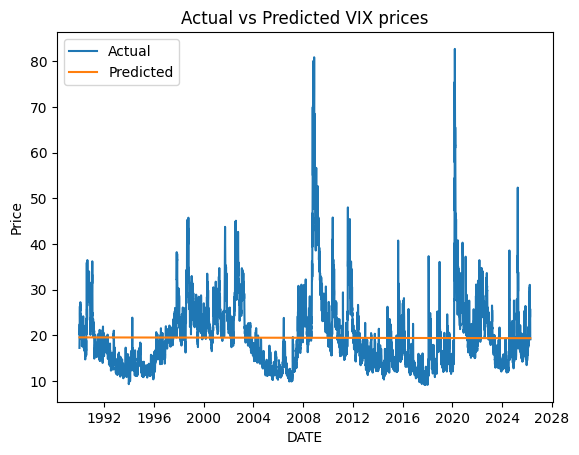

In [ ]:
X = df[['DATE']].apply(lambda col: col.apply(lambda x: x.toordinal()))
Y = df['CLOSE']
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, Y)
df['prediction'] = model.predict(X)
plt.figure()
plt.plot(df['DATE'], df['CLOSE'], label='Actual')
plt.plot(df['DATE'],df['prediction'], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted VIX prices")
plt.xlabel("DATE")
plt.ylabel("Price")
plt.show()

## polynomial regression

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
poly = PolynomialFeatures(degree=2)
X_poly_= poly.fit_transform(X)
poly_model = LinearRegression()
poly_model.fit(X_poly_,Y)
df['poly_prediction'] = poly_model.predict(X_poly_)


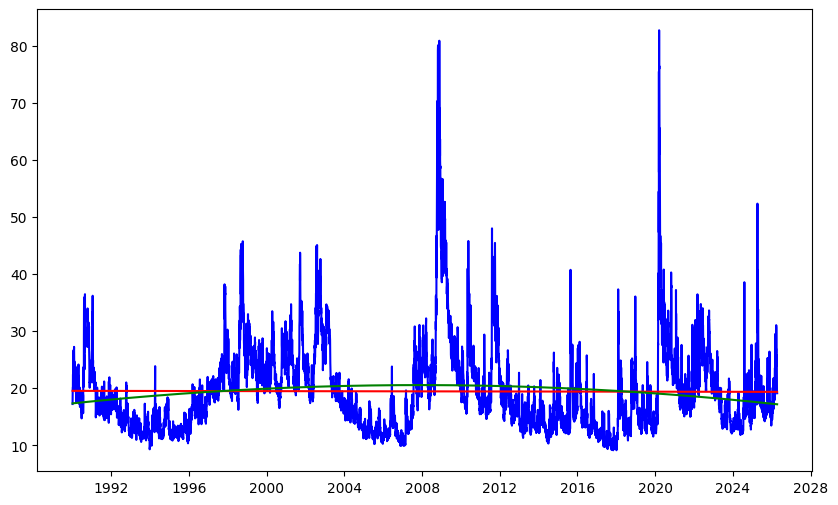

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df['DATE'], df['CLOSE'], label='Actual',color='blue')
plt.plot(df['DATE'], df['prediction'], label='Linear prediction', color = 'red')
plt.plot(df['DATE'],df['poly_prediction'], color = 'green')

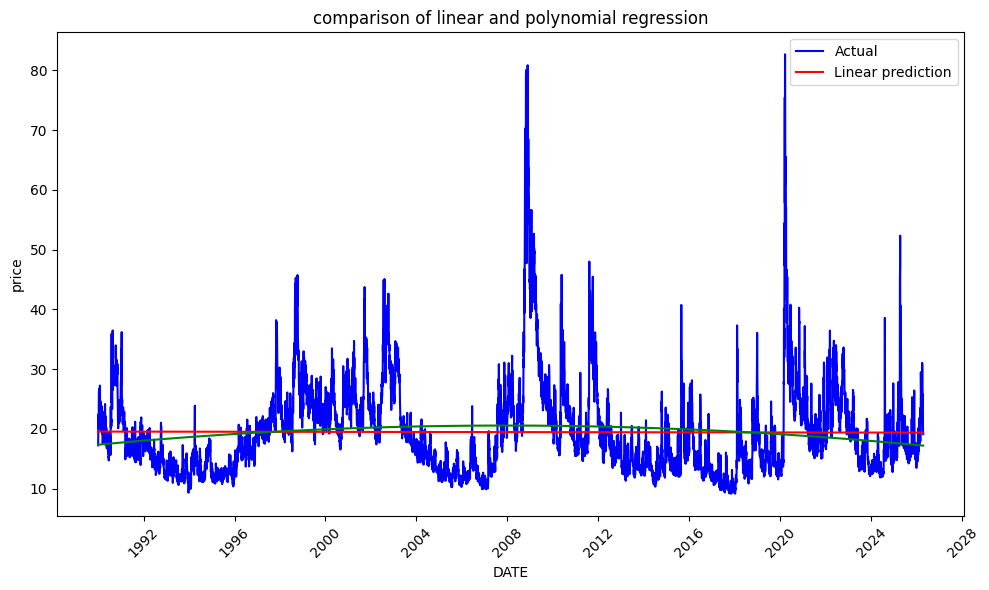

In [ ]:


plt.figure(figsize=(10, 6))
plt.plot(df['DATE'], df['CLOSE'], label='Actual',color='blue')
plt.plot(df['DATE'], df['prediction'], label='Linear prediction', color = 'red')
plt.plot(df['DATE'],df['poly_prediction'], color = 'green')
plt.legend()
plt.title('comparison of linear and polynomial regression')
plt.xlabel('DATE')
plt.ylabel('price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Evaluation**

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score

print("Linear R2:",r2_score(Y,df['prediction']))
print("polynomial R2:",r2_score(Y,df['poly_prediction']))

Linear R2: 4.292170633202197e-05
polynomial R2: 0.016008433517364695
